# Retrain XGBoost on Real Captures (70–30 Split)
### Production-ready model for live demo on your own setup

This notebook:
1. Loads and combines `live1` + `live2` (your own labeled captures)
2. Does thorough EDA and class balance check
3. Trains XGBoost with 70–30 stratified split
4. Evaluates with classification report + confusion matrix
5. Saves the trained model and label encoder for deployment

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_recall_fscore_support)
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Your Real Captures

In [3]:
# ── UPDATE THESE PATHS ───────────────────────────────────────────────────────
LIVE1_PATH = r"C:\Users\magan\Downloads\HPE Project\CSV's\label_realdata_flows.csv"
LIVE2_PATH = r"C:\Users\magan\Downloads\HPE Project\CSV's\port_brute_labeled.csv"

# Output paths
MODEL_SAVE_PATH  = r"C:\Users\magan\Downloads\HPE Project\xgb_realcapture.json"
ENCODER_SAVE_PATH = r"C:\Users\magan\Downloads\HPE Project\label_encoder.pkl"
FEATURE_SAVE_PATH = r"C:\Users\magan\Downloads\HPE Project\feature_columns.pkl"

live1 = pd.read_csv(LIVE1_PATH)
live2 = pd.read_csv(LIVE2_PATH)

for df in [live1, live2]:
    df.columns = df.columns.str.strip()

print('live1 shape:', live1.shape)
print('live2 shape:', live2.shape)
print()
print('live1 labels:')
print(live1['Label'].value_counts())
print()
print('live2 labels:')
print(live2['Label'].value_counts())

live1 shape: (25709, 84)
live2 shape: (83897, 84)

live1 labels:
Label
PortScan      16983
BENIGN         8577
BruteForce      149
Name: count, dtype: int64

live2 labels:
Label
PortScan          75700
BENIGN             7633
FTP-BruteForce      454
SSH-BruteForce      110
Name: count, dtype: int64


## 2. Standardise Labels

In [4]:
# Normalise label names across both files
# live1 uses 'BruteForce', live2 uses 'SSH-BruteForce'/'FTP-BruteForce'
# We map everything to CIC-style names for consistency
live1['Label'] = live1['Label'].replace({
    'BruteForce': 'SSH-Patator'   # adjust if yours is FTP — check the dst port
})
live2['Label'] = live2['Label'].replace({
    'SSH-BruteForce': 'SSH-Patator',
    'FTP-BruteForce': 'FTP-Patator'
})

# Combine
df = pd.concat([live1, live2], axis=0, ignore_index=True)

print('Combined shape:', df.shape)
print()
print('Final label distribution:')
vc = df['Label'].value_counts()
for label, cnt in vc.items():
    print(f'  {label:<20}: {cnt:>7,}  ({cnt/len(df)*100:.1f}%)')

Combined shape: (109606, 84)

Final label distribution:
  PortScan            :  92,683  (84.6%)
  BENIGN              :  16,210  (14.8%)
  FTP-Patator         :     454  (0.4%)
  SSH-Patator         :     259  (0.2%)


## 3. Drop Meta Columns

In [5]:
META_COLS = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Protocol', 'Timestamp']

# Drop meta + zero-variance bulk features (same as original notebook)
ZERO_VARIANCE_COLS = [
    'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
    'CWR Flag Count',  # note: your CICFlowMeter uses CWR not CWE
    'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
    'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg'
]

DROP_COLS = META_COLS + ZERO_VARIANCE_COLS
df1 = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

print('Columns after dropping meta/zero-variance:', df1.shape[1] - 1, 'features + Label')
print('Remaining columns:')
print([c for c in df1.columns if c != 'Label'])

Columns after dropping meta/zero-variance: 67 features + Label
Remaining columns:
['Dst Port', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 

## 4. Check and Verify Zero-Variance Columns

In [6]:
# Check if any remaining columns have near-zero variance (won't help the model)
feature_cols = [c for c in df1.columns if c != 'Label']
X_check = df1[feature_cols].apply(pd.to_numeric, errors='coerce')

low_var = X_check.std().sort_values().head(10)
print('Lowest std-dev features (potential zero-variance):')
print(low_var)

# Drop any column that is literally constant across all rows
truly_zero = X_check.columns[X_check.std() == 0].tolist()
if truly_zero:
    print(f'\nDropping {len(truly_zero)} truly constant columns: {truly_zero}')
    df1 = df1.drop(columns=truly_zero)
else:
    print('\nNo truly constant columns found — good.')

Lowest std-dev features (potential zero-variance):
ECE Flag Count       0.0000
URG Flag Count       0.0953
Fwd PSH Flags        0.1275
Down/Up Ratio        0.2350
RST Flag Count       0.3537
FIN Flag Count       0.3879
SYN Flag Count       0.4195
Fwd Seg Size Min     5.3144
Fwd Act Data Pkts   16.3288
Packet Length Min   20.5191
dtype: float64

Dropping 1 truly constant columns: ['ECE Flag Count']


## 5. Prepare Features and Handle Inf/NaN

In [7]:
X = df1.drop('Label', axis=1).apply(pd.to_numeric, errors='coerce')
y = df1['Label']

print('Before cleaning:')
print(f'  Inf values : {np.isinf(X).sum().sum()}')
print(f'  NaN values : {np.isnan(X).sum().sum()}')

# Replace inf with NaN, then fill NaN with column median
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print('After cleaning:')
print(f'  Inf values : {np.isinf(X).sum().sum()}')
print(f'  NaN values : {np.isnan(X).sum().sum()}')
print(f'\nFinal feature matrix: {X.shape}')

Before cleaning:
  Inf values : 396
  NaN values : 386
After cleaning:
  Inf values : 0
  NaN values : 0

Final feature matrix: (109606, 66)


## 6. Encode Labels

In [8]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label encoding:')
for cls, idx in sorted(label_mapping.items(), key=lambda x: x[1]):
    cnt = (y == cls).sum()
    print(f'  {idx}: {cls:<20}  ({cnt:,} samples)')

Label encoding:
  0: BENIGN                (16,210 samples)
  1: FTP-Patator           (454 samples)
  2: PortScan              (92,683 samples)
  3: SSH-Patator           (259 samples)


## 7. Class Balance Check and Strategy

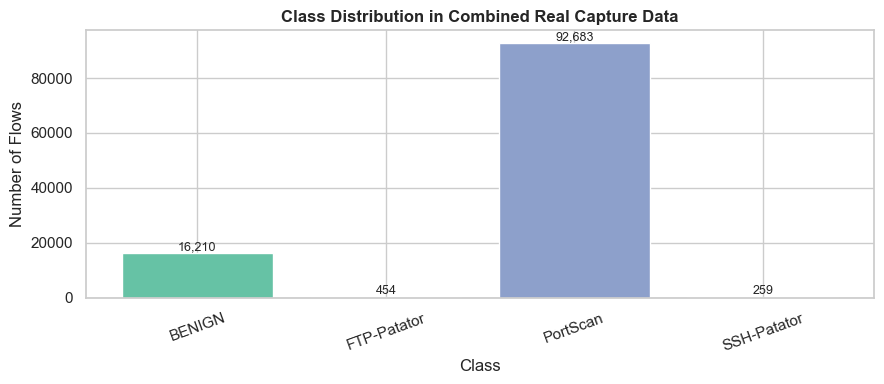

Imbalance ratio (max/min): 357.8x
⚠ High imbalance — XGBoost scale_pos_weight / sample_weight may help for minority classes


In [9]:
class_counts = pd.Series(y_enc).value_counts().sort_index()
class_names  = le.inverse_transform(class_counts.index)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_names, class_counts.values,
              color=sns.color_palette('Set2', len(class_names)))
ax.set_title('Class Distribution in Combined Real Capture Data', fontsize=12, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Flows')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution_realdata.png', dpi=150, bbox_inches='tight')
plt.show()

# Check imbalance ratio
max_cls = class_counts.max()
min_cls = class_counts.min()
print(f'Imbalance ratio (max/min): {max_cls/min_cls:.1f}x')
if max_cls/min_cls > 20:
    print('⚠ High imbalance — XGBoost scale_pos_weight / sample_weight may help for minority classes')
else:
    print('✓ Acceptable imbalance for XGBoost with stratified split')

## 8. Train–Test Split (70–30 Stratified)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.30,       # 30% held out
    stratify=y_enc,       # preserve class proportions in both sets
    random_state=42
)

print(f'Train set : {X_train.shape[0]:,} samples')
print(f'Test set  : {X_test.shape[0]:,} samples')
print()
print('Train class distribution:')
for cls_idx, cnt in pd.Series(y_train).value_counts().sort_index().items():
    print(f'  {le.inverse_transform([cls_idx])[0]:<20}: {cnt:>6,}')
print()
print('Test class distribution:')
for cls_idx, cnt in pd.Series(y_test).value_counts().sort_index().items():
    print(f'  {le.inverse_transform([cls_idx])[0]:<20}: {cnt:>6,}')

Train set : 76,724 samples
Test set  : 32,882 samples

Train class distribution:
  BENIGN              : 11,347
  FTP-Patator         :    318
  PortScan            : 64,878
  SSH-Patator         :    181

Test class distribution:
  BENIGN              :  4,863
  FTP-Patator         :    136
  PortScan            : 27,805
  SSH-Patator         :     78


## 9. Compute Class Weights (handles minority classes)

In [11]:
# Compute per-sample weights so XGBoost pays more attention to small classes
# (SSH-Patator, FTP-Patator are rare)
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print('Sample weight stats:')
print(f'  Min  : {sample_weights.min():.4f}')
print(f'  Max  : {sample_weights.max():.4f}')
print(f'  Mean : {sample_weights.mean():.4f}')
print()
print('(Higher weight = model pays more attention during training)')

Sample weight stats:
  Min  : 0.2956
  Max  : 105.9724
  Mean : 1.0000

(Higher weight = model pays more attention during training)


## 10. Train XGBoost on Real Captures

In [12]:
xg_real = xgb.XGBClassifier(
    # ── Task ─────────────────────────────────────────────────────────────────
    objective='multi:softprob',
    num_class=len(le.classes_),

    # ── Tree structure ────────────────────────────────────────────────────────
    n_estimators=300,         # more trees since dataset is smaller
    max_depth=6,              # slightly shallower — real data is noisier
    learning_rate=0.05,       # lower LR + more trees = better generalisation

    # ── Regularisation ────────────────────────────────────────────────────────
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,       # prevents overfitting to tiny minority class flows
    gamma=0.1,                # minimum loss reduction to split
    reg_lambda=1.0,           # L2 regularisation

    # ── Speed ─────────────────────────────────────────────────────────────────
    tree_method='hist',

    # ── Reproducibility ───────────────────────────────────────────────────────
    random_state=42,
    eval_metric='mlogloss',
    early_stopping_rounds=20,  # stop if val loss doesn't improve for 20 rounds
    verbose=False
)

print('Training XGBoost on real capture data...')
xg_real.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print(f'\nTraining complete. Best iteration: {xg_real.best_iteration}')

Training XGBoost on real capture data...
[0]	validation_0-mlogloss:1.28824
[50]	validation_0-mlogloss:0.08321
[100]	validation_0-mlogloss:0.00737
[150]	validation_0-mlogloss:0.00115
[200]	validation_0-mlogloss:0.00058
[250]	validation_0-mlogloss:0.00052
[299]	validation_0-mlogloss:0.00050

Training complete. Best iteration: 296


## 11. Evaluate on Test Set

In [13]:
y_pred = xg_real.predict(X_test)

print('=== TEST SET RESULTS (30% holdout) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== TEST SET RESULTS (30% holdout) ===
Accuracy: 0.9999

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      4863
 FTP-Patator       0.99      1.00      1.00       136
    PortScan       1.00      1.00      1.00     27805
 SSH-Patator       1.00      1.00      1.00        78

    accuracy                           1.00     32882
   macro avg       1.00      1.00      1.00     32882
weighted avg       1.00      1.00      1.00     32882



## 12. Confusion Matrix

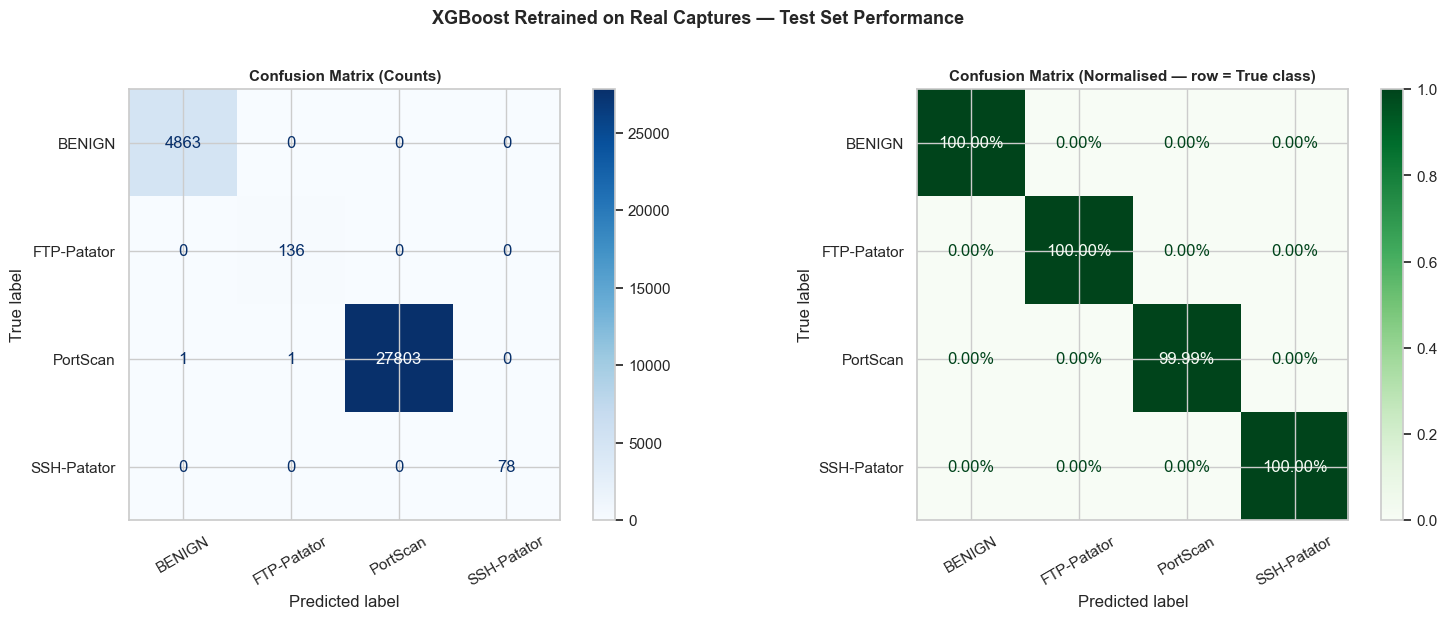

Saved: confusion_matrix_retrained.png


In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=True, cmap='Blues', xticks_rotation=30)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=11, fontweight='bold')

# Normalised (row = true class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le.classes_).plot(
    ax=axes[1], colorbar=True, cmap='Greens', xticks_rotation=30, values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalised — row = True class)', fontsize=11, fontweight='bold')

plt.suptitle('XGBoost Retrained on Real Captures — Test Set Performance', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_retrained.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_retrained.png')

## 13. Per-Class Performance Chart

=== Per-Class Performance ===
      Class  Precision  Recall  F1-Score  Support
     BENIGN     0.9998  1.0000    0.9999     4863
FTP-Patator     0.9927  1.0000    0.9963      136
   PortScan     1.0000  0.9999    1.0000    27805
SSH-Patator     1.0000  1.0000    1.0000       78


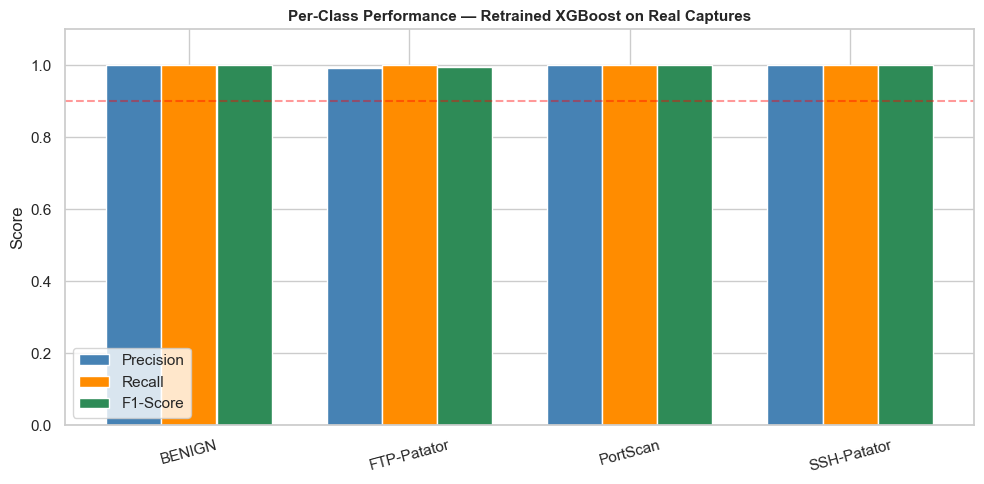

Saved: per_class_performance.png


In [15]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(le.classes_)))

perf_df = pd.DataFrame({
    'Class':     le.classes_,
    'Precision': precision,
    'Recall':    recall,
    'F1-Score':  f1,
    'Support':   support
})

print('=== Per-Class Performance ===')
print(perf_df.to_string(index=False))

# Visual
x = np.arange(len(le.classes_))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x,          recall,   width, label='Recall',    color='darkorange')
ax.bar(x + width,  f1,       width, label='F1-Score',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance — Retrained XGBoost on Real Captures',
             fontsize=11, fontweight='bold')
ax.legend()
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='0.90 threshold')
plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_performance.png')

## 14. Feature Importance

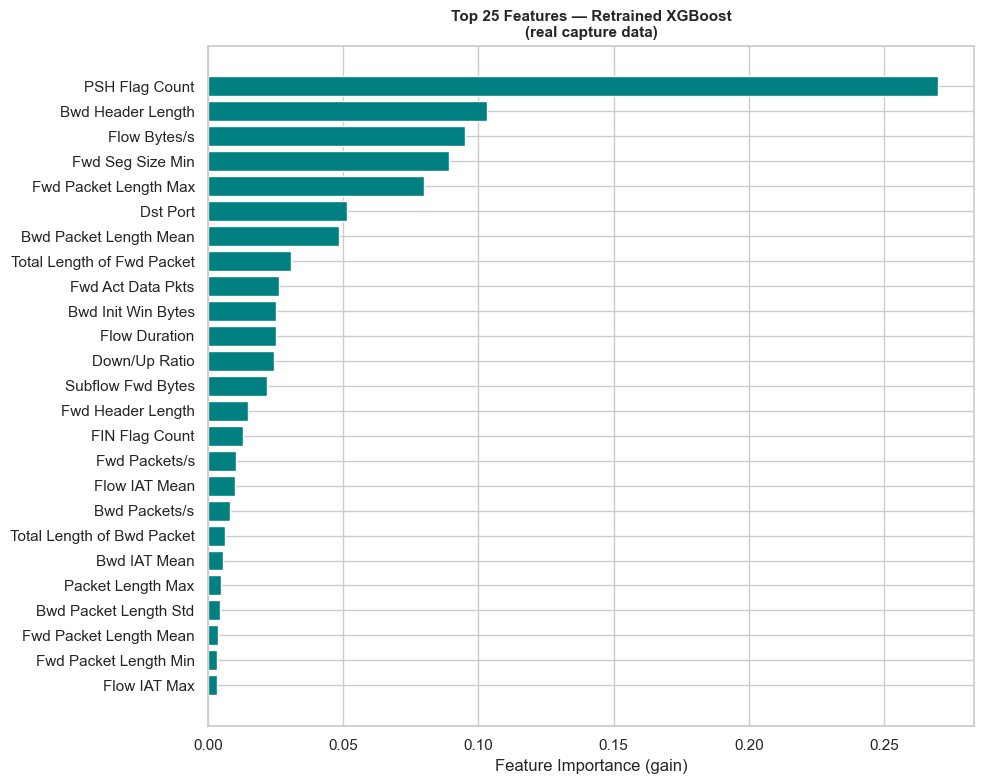

Top 10 features:
                   Feature  Importance
            PSH Flag Count      0.2698
         Bwd Header Length      0.1034
              Flow Bytes/s      0.0949
          Fwd Seg Size Min      0.0891
     Fwd Packet Length Max      0.0799
                  Dst Port      0.0513
    Bwd Packet Length Mean      0.0485
Total Length of Fwd Packet      0.0309
         Fwd Act Data Pkts      0.0264
        Bwd Init Win Bytes      0.0253


In [16]:
importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': xg_real.feature_importances_
}).sort_values('Importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
        color='teal')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 25 Features — Retrained XGBoost\n(real capture data)', 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_retrained.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 10 features:')
print(importance_df.head(10).to_string(index=False))

## 15. Learning Curve (train vs validation loss)

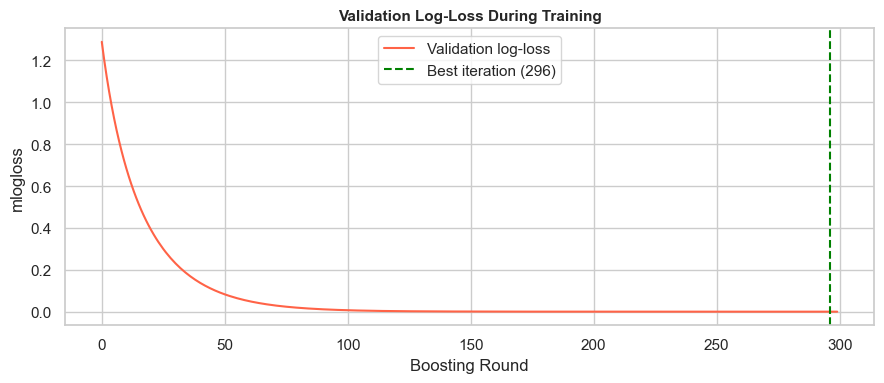

Saved: learning_curve.png


In [17]:
results = xg_real.evals_result()
epochs  = len(results['validation_0']['mlogloss'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(epochs), results['validation_0']['mlogloss'],
        color='tomato', linewidth=1.5, label='Validation log-loss')
ax.axvline(x=xg_real.best_iteration, color='green', linestyle='--',
           label=f'Best iteration ({xg_real.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('mlogloss')
ax.set_title('Validation Log-Loss During Training', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: learning_curve.png')

## 16. Save Model, Encoder and Feature List

In [18]:
# Save the XGBoost model in JSON format (portable)
xg_real.save_model(MODEL_SAVE_PATH)

# Save label encoder and feature column order — REQUIRED for inference
joblib.dump(le, ENCODER_SAVE_PATH)
joblib.dump(list(X_train.columns), FEATURE_SAVE_PATH)

print(f'✓ Model saved    : {MODEL_SAVE_PATH}')
print(f'✓ Encoder saved  : {ENCODER_SAVE_PATH}')
print(f'✓ Features saved : {FEATURE_SAVE_PATH}')
print(f'  ({len(X_train.columns)} features)')

TypeError: `_estimator_type` undefined.  Please use appropriate mixin to define estimator type.

## 17. Inference Template (for live demo)
Use this to predict on a new CICFlowMeter CSV captured during the demo.

In [ ]:
def predict_new_capture(csv_path: str) -> pd.DataFrame:
    """
    Load a new CICFlowMeter CSV and return predictions.
    Returns the original dataframe with a 'Predicted_Label' column appended.
    """
    # Load model, encoder and feature list
    model   = xgb.XGBClassifier()
    model.load_model(MODEL_SAVE_PATH)
    encoder = joblib.load(ENCODER_SAVE_PATH)
    feature_cols = joblib.load(FEATURE_SAVE_PATH)

    # Load new capture
    new_df = pd.read_csv(csv_path)
    new_df.columns = new_df.columns.str.strip()

    # Drop meta columns if present
    drop_meta = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Protocol', 'Timestamp',
                 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWR Flag Count',
                 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
                 'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg']
    new_df_clean = new_df.drop(columns=[c for c in drop_meta if c in new_df.columns])

    # Remove label column if present
    if 'Label' in new_df_clean.columns:
        new_df_clean = new_df_clean.drop('Label', axis=1)

    # Align features — add missing as 0, drop extras
    for col in feature_cols:
        if col not in new_df_clean.columns:
            new_df_clean[col] = 0
    extra = [c for c in new_df_clean.columns if c not in feature_cols]
    new_df_clean = new_df_clean.drop(columns=extra)
    new_df_clean = new_df_clean[feature_cols]  # enforce column order

    # Clean numerics
    X_new = new_df_clean.apply(pd.to_numeric, errors='coerce')
    X_new = X_new.replace([np.inf, -np.inf], np.nan).fillna(X_new.median())

    # Predict
    preds = model.predict(X_new)
    pred_labels = encoder.inverse_transform(preds)

    # Attach predictions to original df
    result = new_df.copy()
    result['Predicted_Label'] = pred_labels

    print('=== Prediction Summary ===')
    print(result['Predicted_Label'].value_counts())
    return result


# ── Usage example: ───────────────────────────────────────────────────────────
# result_df = predict_new_capture(r"C:\path\to\new_capture.csv")
# result_df.to_csv(r"C:\path\to\predictions.csv", index=False)

print('predict_new_capture() function defined.')
print('Call it with the path to any new CICFlowMeter CSV to get predictions.')

## 18. Quick Sanity Check — Predict on own training capture
*(optional — comment out if not needed)*

In [ ]:
# Quick sanity: predict on live2 as a standalone file using the inference function
# result = predict_new_capture(LIVE2_PATH)

# If you want to see probabilities per class:
y_prob = xg_real.predict_proba(X_test)
prob_df = pd.DataFrame(y_prob, columns=[f'P({c})' for c in le.classes_])
prob_df['True_Label']      = le.inverse_transform(y_test)
prob_df['Predicted_Label'] = le.inverse_transform(y_pred)
prob_df['Correct']         = prob_df['True_Label'] == prob_df['Predicted_Label']

print('Sample predictions with confidence scores:')
print(prob_df.sample(10, random_state=1).to_string(index=False))